In [125]:
import pandas as pd 
from scipy import fftpack
import numpy as np
import matplotlib.pyplot as plt
import os 
from vmdpy import VMD

In [126]:

file_path='../../数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv'
df=pd.read_csv(file_path,usecols=['CH17'])
data = df.iloc[:, 0].values
data = data[:64000]

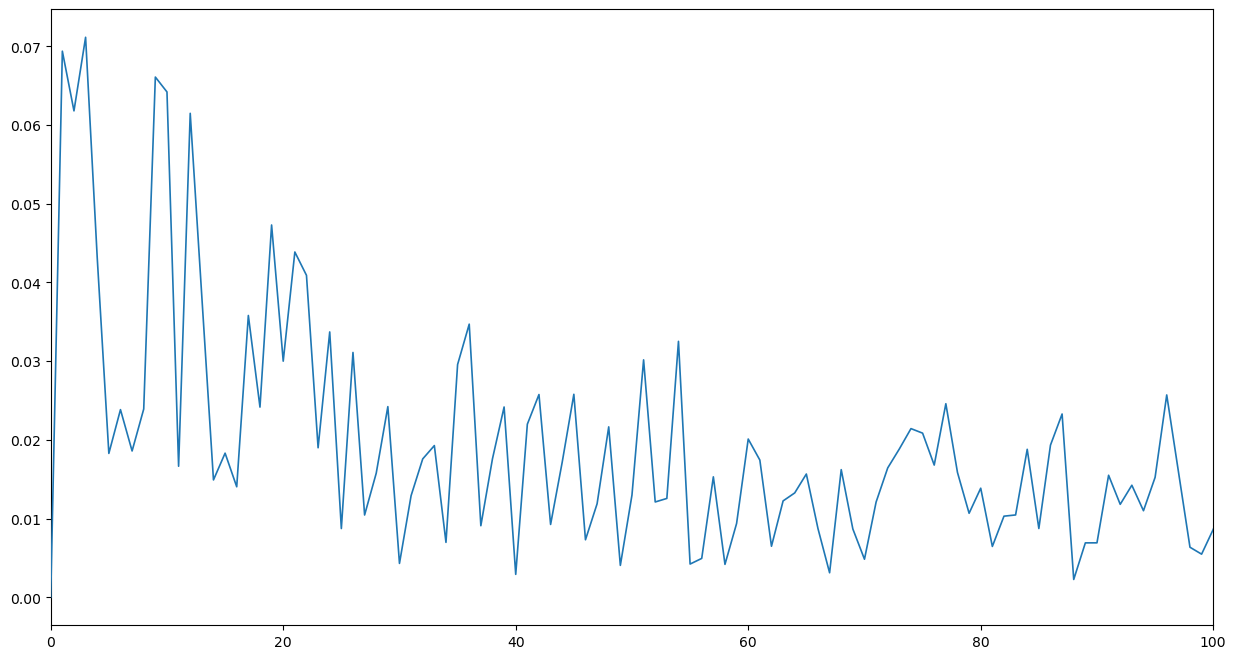

In [127]:

max_points=64000
fs=64000
xt = data[:max_points]
ht=fftpack.hilbert(data)
at=np.sqrt(xt**2+ht**2)
at=at-np.mean(at)
n=len(at)
am=np.abs(np.fft.fft(at))
am = (am / n) * 2

# 取正频率部分
half_n = n // 2
freq = np.fft.fftfreq(n, d=1 / fs)[:half_n]
amp = am[:half_n]



plt.figure(figsize=(15,8))
plt.plot(freq, amp, color='#1f77b4', lw=1.2, label='包络幅值', zorder=3)
plt.xlim([0, 100])
plt.show()

In [128]:
K=4 #设置分解层数
alpha=2000 #设置惩罚因子
tau=0 #设置噪声容量
n_iter=300 #迭代次数
DC=0
init=1
tol=1e-7
t=np.linspace(0, 1, 64000)  # 时间向量


In [129]:
u,u_hat,omega=VMD(data,alpha,tau,K,DC,init,tol)

In [130]:
u=u.T
len(u)


64000

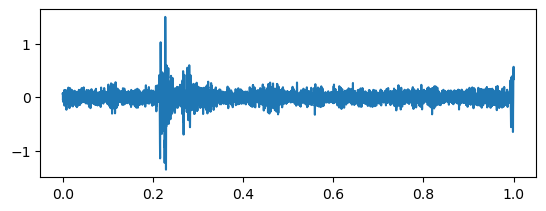

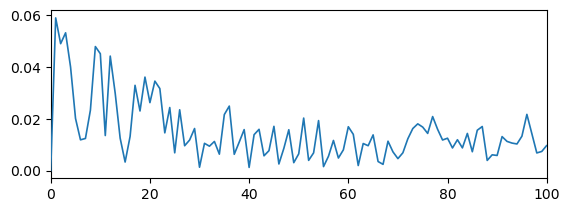

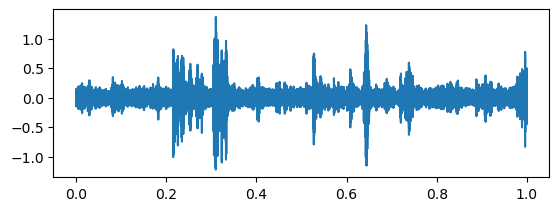

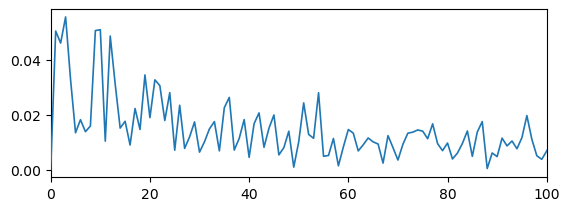

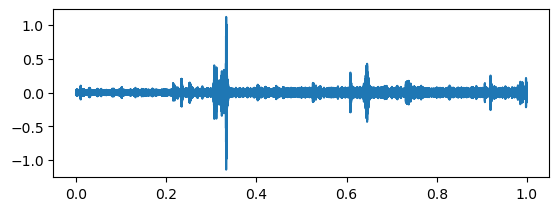

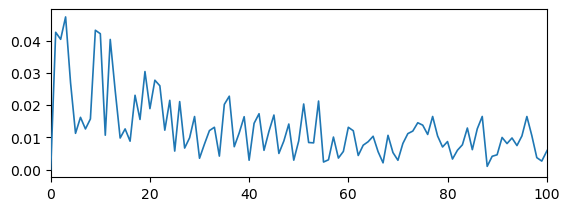

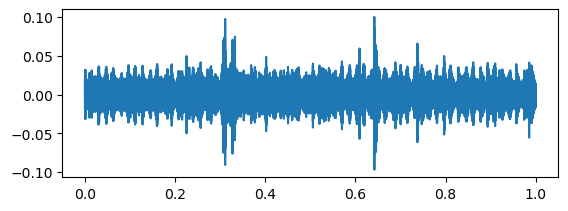

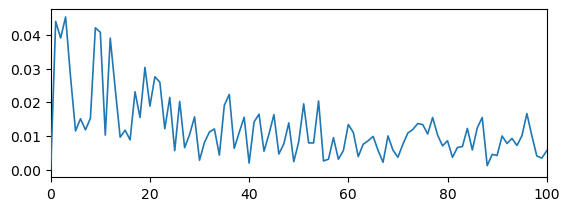

In [131]:


for i in range(4):
    plt.subplot(2,1,1)
    plt.plot(t,u[:,i])
    plt.show()
    max_points=64000
    fs=64000
    xt = u[:max_points,i]
    ht=fftpack.hilbert(data)
    at=np.sqrt(xt**2+ht**2)
    at=at-np.mean(at)
    n=len(at)
    am=np.abs(np.fft.fft(at))
    am = (am / n) * 2
    # 取正频率部分
    half_n = n // 2
    freq = np.fft.fftfreq(n, d=1 / fs)[:half_n]
    amp = am[:half_n]
    plt.subplot(2,1,2)
    plt.plot(freq, amp, color='#1f77b4', lw=1.2, label='包络幅值', zorder=3)
    plt.xlim([0, 100])
    plt.show()

  
